# Reproducing the paper figures

This notebook reproduces the figures of the online amplitude-encoding quantum reservoir computing manuscript from saved data files. The data are assumed to be available locally, e.g. after downloading the Zenodo archive, with the same relative folder structure used below.

The notebook is organized figure by figure. It does not regenerate the raw quantum trajectories from circuits; instead, it loads the saved expectation values and recomputes the post-processing steps needed for the published plots.

## Setup

The first cells collect common imports and load the paper plotting style. The variable `orig_rc` stores the original Matplotlib configuration in case you want to restore it later.

In [1]:
# Core imports used throughout the reproduction notebook.
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression
from tqdm import tqdm

In [2]:
# -----------------------------------------------------------------------------
# User-editable paths
# -----------------------------------------------------------------------------
# Point DATA_DIR to the folder that contains the downloaded data archive.
# The default assumes that the notebook is executed from the re
# pository folder
# with the same relative structure used when the data were generated.
DATA_DIR = Path("../")
DATASET_DIR = Path("../../")

# Main data locations. Edit these paths if your Zenodo/data folder is elsewhere.
PAPER_FIGURE_DATA_DIR = DATA_DIR / "data_fig2"
HARDWARE_DATA_DIR = DATA_DIR / "data_hardware"
G_SCAN_DATA_DIR = DATA_DIR / "data_g"
SANTA_FE_PATH = DATASET_DIR / "sk_Santa_Fe_2000.npy"

# Plot style and output folder.
PLOT_STYLE_PATH = Path("./plot_params/paper.json")
OUTPUT_FIGURE_DIR = DATA_DIR / "figures"
OUTPUT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
import json
with open(PLOT_STYLE_PATH, "r") as read_content:
    qplot_params = json.load(read_content)
orig_rc = plt.rcParams.copy()
dict.update(plt.rcParams, qplot_params)

## Figure 2 — spin-model versus circuit-model dynamics

This section reproduces the comparison between the ideal spin-model evolution and the density-matrix circuit model. The data are loaded from a precomputed pickle file containing the expectation values of the input qubit and of one indirectly measured memory qubit.

In [4]:
# Load precomputed expectation values for the Fig. 2 comparison.
with open(PAPER_FIGURE_DATA_DIR / "fig_data_qiskit_vs_spin.pkl", "rb") as f:
    fig_data = pickle.load(f)

exp_values = fig_data["exp_values"]
exp_values_input = fig_data["exp_values_input"]
exp_values_qiskit = fig_data["exp_values_qiskit"]
exp_values_input_qiskit = fig_data["exp_values_input_qiskit"]

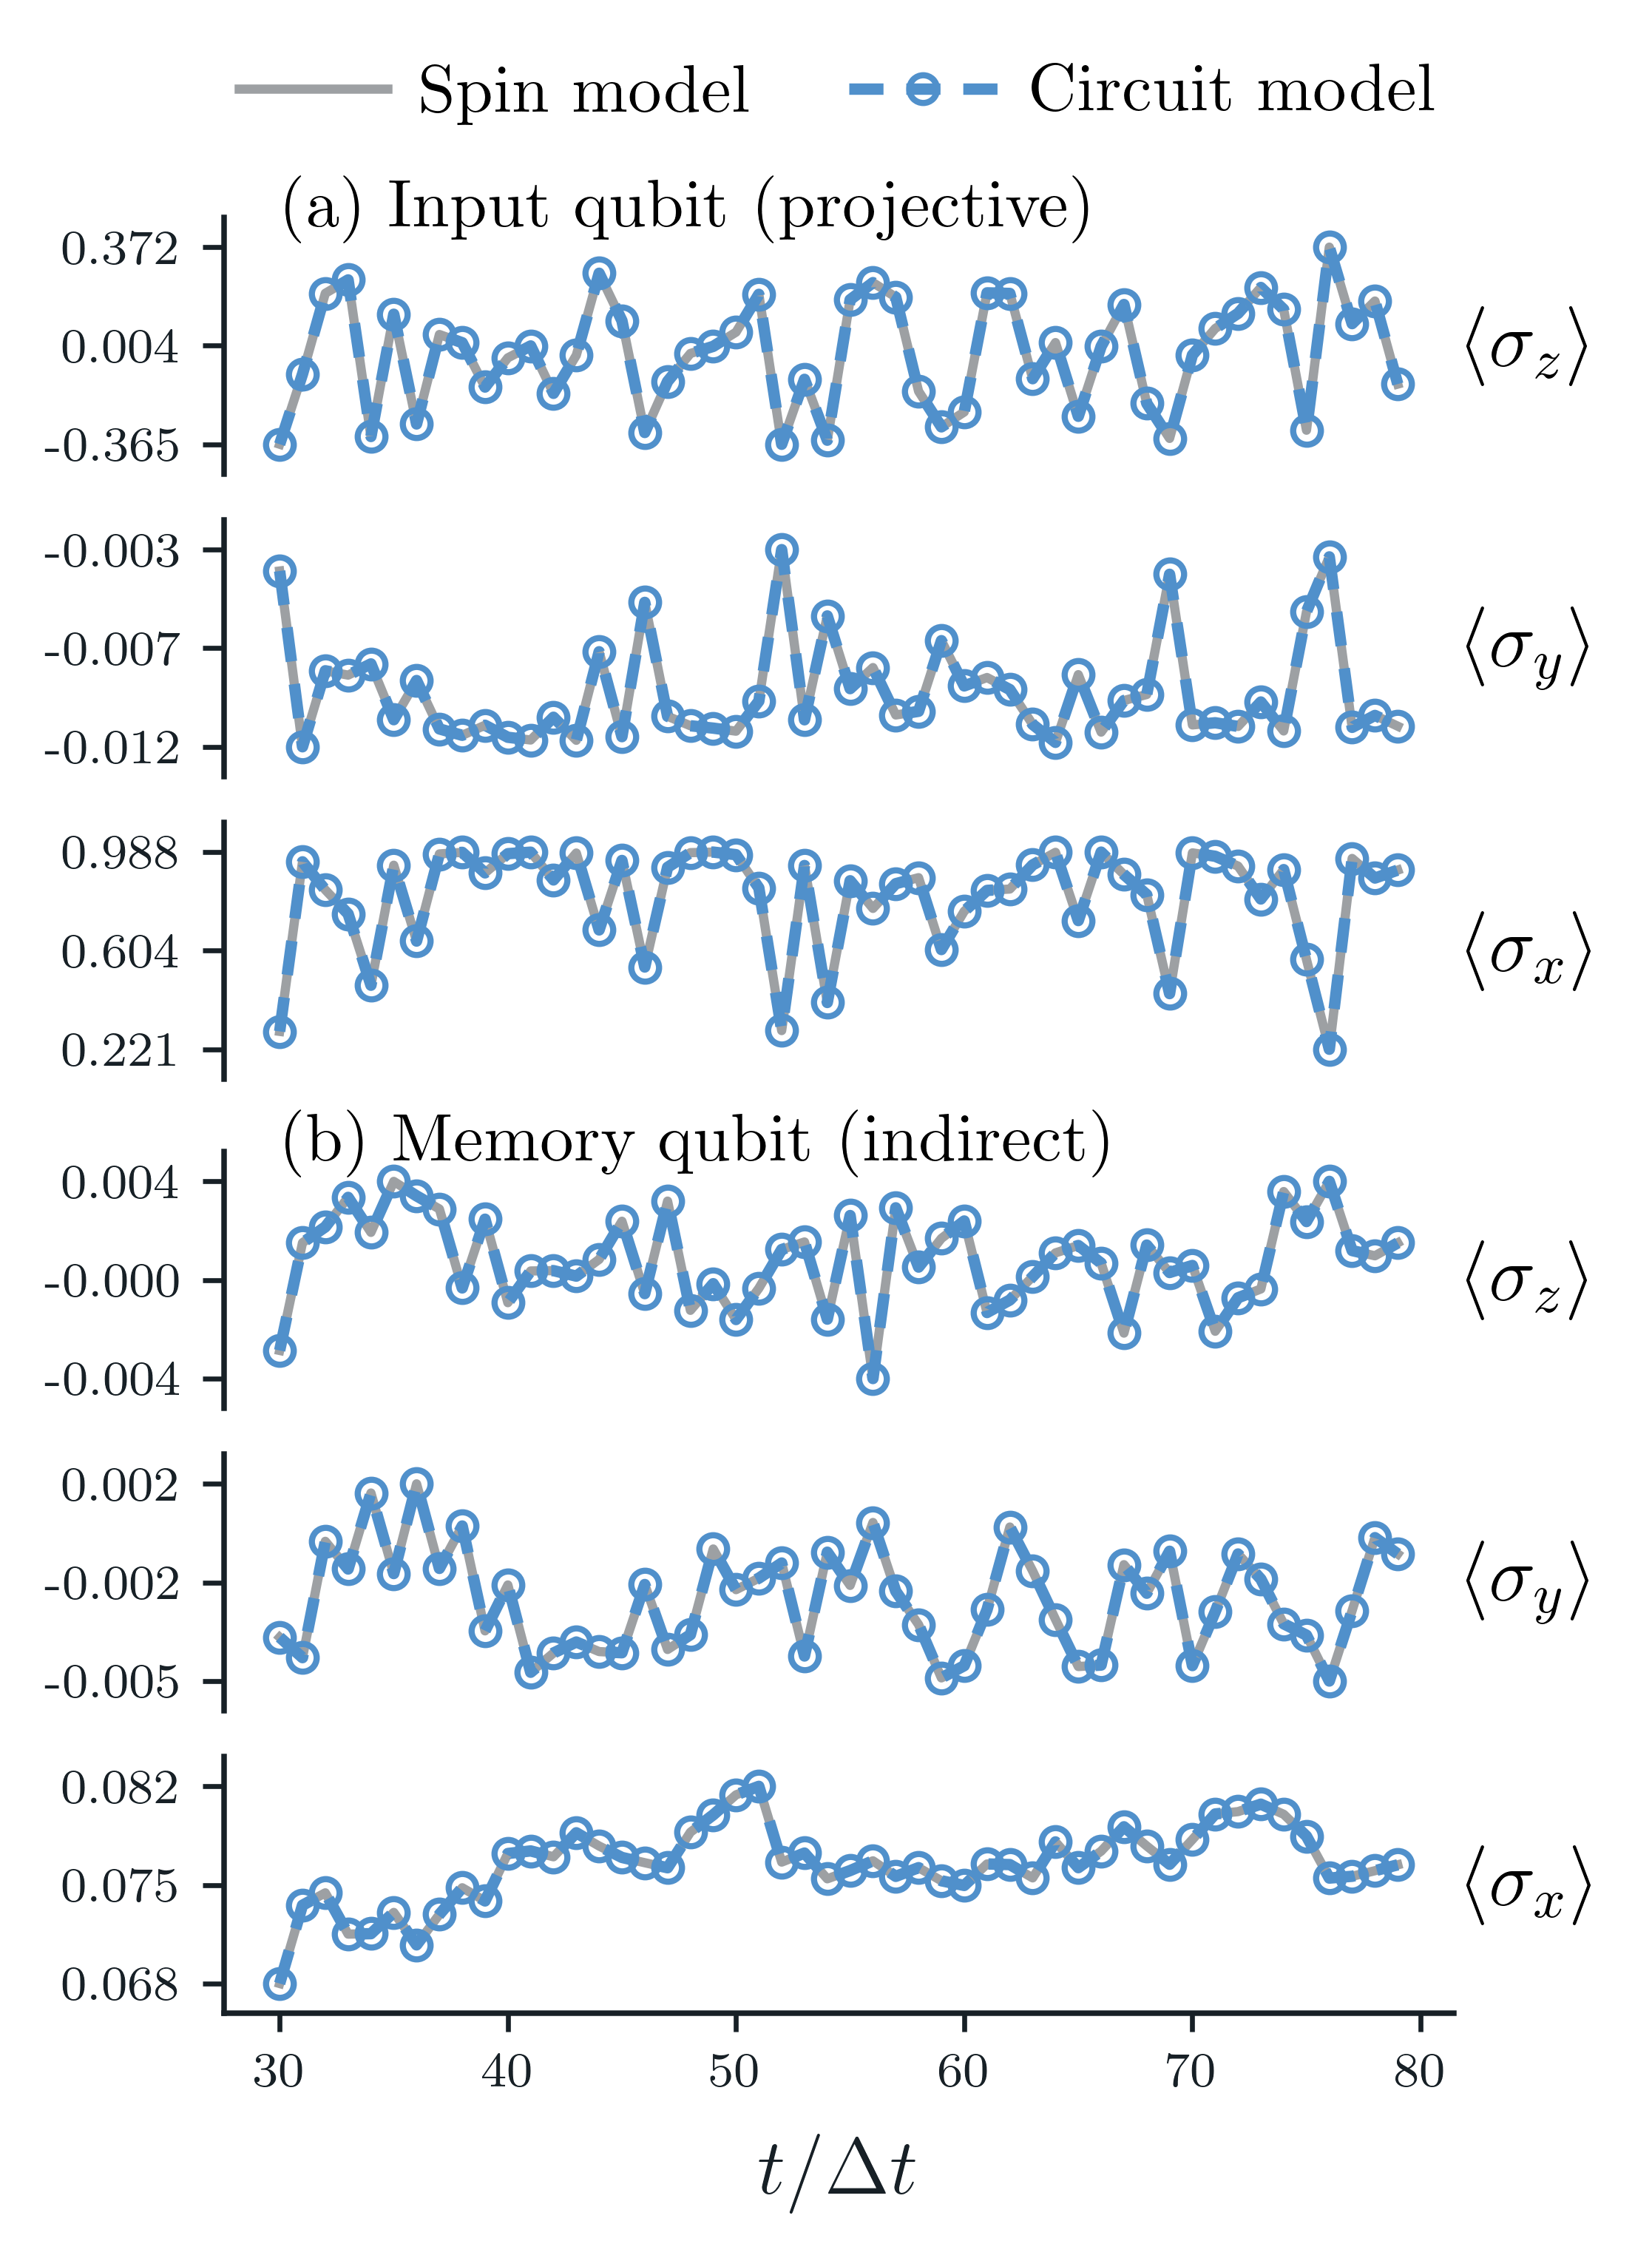

In [21]:
obs_order = ['Z', 'Y', 'X']

colors_palette = [
    "#9DA0A3FF",   # ideal
    "#5090cb",     # simulation
    "#0d3b66",     # hardware
]

markers = ['o', 'o', 'o']

K = 1000
line_w = 1.5
marker_size = 4

start = 30
end = 80
x = np.arange(K)[start:end]


# --------------------------------------------------------
# scaling, limits and ticks
# --------------------------------------------------------

def compute_lims_and_ticks(y, yq, pad_frac=0.15, min_span=1e-4):
    y_all = np.concatenate([
        np.asarray(y).ravel(),
        np.asarray(yq).ravel()
    ])

    ymin, ymax = float(np.min(y_all)), float(np.max(y_all))
    span = max(ymax - ymin, min_span)

    pad = pad_frac * span
    ylim = (ymin - pad, ymax + pad)

    ticks = np.linspace(ymin, ymax, 3)
    ticklabels = [f"{t:.3f}" for t in ticks]

    return ylim, ticks, ticklabels


# --------------------------------------------------------
# plotting helper
# --------------------------------------------------------

def plot_one(ax, x, y, yq, obs):

    ylim, yticks, yticklabels = compute_lims_and_ticks(y, yq)

    # Ideal
    ax.plot(
        x, y,
        color=colors_palette[0],
        lw=line_w,
        zorder=2
    )

    # Circuit simulation
    ax.plot(
        x, yq,
        color=colors_palette[1],
        linestyle=(0, (3, 2)),
        linewidth=1.85,
        zorder=3,
        marker = 'o',
        markerfacecolor = 'none'
    )


    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)

    ax.tick_params(axis='x', length=0)
    ax.minorticks_off()

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # observable label on right
    ax.text(
        1.01, 0.5,
        rf'$\langle \sigma_{{{obs.lower()}}}\rangle$',
        transform=ax.transAxes,
        va='center',
        ha='left',
        fontsize=13
    )


# --------------------------------------------------------
# layout with dedicated legend strip
# --------------------------------------------------------

fig = plt.figure(
    figsize=(3.85, 5.1),
    dpi=600
)

outer = fig.add_gridspec(
    3, 1,
    height_ratios=[0.35, 3, 3],
    hspace=0.12
)

# legend row
ax_leg = fig.add_subplot(outer[0])
ax_leg.axis('off')

# two stacked groups
gs_top = outer[1].subgridspec(
    3, 1,
    hspace=0.18
)

gs_bot = outer[2].subgridspec(
    3, 1,
    hspace=0.18
)

axes_in = [
    fig.add_subplot(gs_top[i,0])
    for i in range(3)
]

axes_mem = [
    fig.add_subplot(gs_bot[i,0], sharex=axes_in[0])
    for i in range(3)
]


# --------------------------------------------------------
# input qubit
# --------------------------------------------------------

for ax, obs in zip(axes_in, obs_order):

    y  = np.array(exp_values_input[obs][start:end])
    yq = np.array(exp_values_input_qiskit[obs][start:end])

    plot_one(
        ax,
        x,
        y,
        yq,
        obs
    )


# --------------------------------------------------------
# memory qubit
# --------------------------------------------------------

for ax, obs in zip(axes_mem, obs_order):

    y  = np.array(exp_values[obs][start:end])
    yq = np.array(exp_values_qiskit[obs][start:end])

    plot_one(
        ax,
        x,
        y,
        yq,
        obs
    )


# --------------------------------------------------------
# subgroup labels inside first subplot
# --------------------------------------------------------

axes_in[0].text(
    0.05, 0.9,
    r'(a) Input qubit (projective)',
    transform=axes_in[0].transAxes,
    ha='left',
    va='bottom',
    fontsize=11
)

axes_mem[0].text(
    0.05, 0.9,
    r'(b) Memory qubit (indirect)',
    transform=axes_mem[0].transAxes,
    ha='left',
    va='bottom',
    fontsize=11
)


# --------------------------------------------------------
# single horizontal legend in dedicated strip
# --------------------------------------------------------

legend_handles = [
    Line2D(
        [0],[0],
        color=colors_palette[0],
        lw=line_w,
        linestyle='-',
        label='Spin model'
    ),

    Line2D(
        [0],[0],
        color=colors_palette[1],
        lw=1.85,
        linestyle= (0, (3, 2)),#'--',
        label='Circuit model',
        marker = 'o',
        markerfacecolor = 'none'
    )]

ax_leg.legend(
    handles=legend_handles,
    loc='center',
    ncol=3,
    frameon=False,
    fontsize=11,
    handlelength=2.2,
    columnspacing=1.4
)


# --------------------------------------------------------
# x-axis
# --------------------------------------------------------

for ax in axes_in:
    ax.tick_params(
        axis='x',
        labelbottom=False
    )

for ax in axes_mem[:-1]:
    ax.tick_params(
        axis='x',
        labelbottom=False
    )

axes_mem[-1].set_xlabel(
    r'$t/\Delta t$',
    fontsize=13
)

axes_mem[-1].tick_params(
    axis='x',
    length=3
)

axes_mem[-1].xaxis.labelpad = 6


# remove bottom spines except last
for ax in axes_in:
    ax.spines['bottom'].set_visible(False)

for ax in axes_mem[:-1]:
    ax.spines['bottom'].set_visible(False)


# --------------------------------------------------------
# final spacing
# --------------------------------------------------------

fig.subplots_adjust(
    top=0.96,
    bottom=0.09,
    left=0.16,
    right=0.88
)
plt.savefig('../figures/paper/figure_2_1.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

## Figure 3 — benchmark capacities

This section computes the forecasting and short-term-memory capacities from the saved ideal, simulator, and hardware expectation values. The same 70/30 train-test split and capacity definition used in the paper are applied to each delay value.

In [22]:
def compute_capacity(features_df, time_series, eta, f_p=True, train=False):
    """Compute the train and test capacity for a fixed delay.

    Parameters
    ----------
    features_df : pandas.DataFrame
        Reservoir features used as the linear readout layer.
    time_series : array-like
        Input sequence used to define the target.
    eta : int
        Delay. For forecasting, the target is shifted forward; for STM,
        the target is shifted backward.
    f_p : bool
        If True, compute the forecasting target. If False, compute the STM target.
    train : bool
        Kept for compatibility with earlier versions of the notebook.
    """
    tot_width = features_df.shape[1]

    N_raw_data = len(features_df)
    N_skip = 50
    data_size = N_raw_data - N_skip
    N_total = data_size

    # Build the design matrix and the unshifted target sequence.
    X_data = features_df.iloc[N_skip:N_skip + data_size, :].to_numpy(dtype=float)
    Y_ini_data = np.asarray(time_series[N_skip:N_skip + data_size], dtype=float).reshape(-1, 1)

    eta = abs(eta)
    # Negative shift gives forecasting; positive shift gives memory.
    if f_p:
        eta = -eta

    Y_data = np.roll(Y_ini_data, eta, axis=0)

    fraction_train = 0.7
    N_train = int(fraction_train * N_total)
    N_test = N_total - N_train

    X_train = X_data[:N_train, :].astype(float)
    y_train = Y_data[:N_train].astype(float)

    X_test = X_data[-N_test:, :].astype(float)
    y_test = Y_data[-N_test:].astype(float)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Flatten to one dimension for covariance and variance calculations.
    y_train = y_train.ravel()
    y_test = y_test.ravel()
    y_train_pred = y_train_pred.ravel()
    y_test_pred = y_test_pred.ravel()

    absolutcapacity_train = np.cov(y_train, y_train_pred, ddof=1)[0, 1]**2 / (
        np.var(y_train, ddof=1) * np.var(y_train_pred, ddof=1)
    )

    absolutcapacity_test = np.cov(y_test, y_test_pred, ddof=1)[0, 1]**2 / (
        np.var(y_test, ddof=1) * np.var(y_test_pred, ddof=1)
    )

    if not train:
        return absolutcapacity_test

    return absolutcapacity_train, absolutcapacity_test

In [23]:
# Load one JSON file containing ideal, simulator, and hardware trajectories.
def load_exp_values(path):
    """Read a saved expectation-value JSON file."""
    with open(path, "r") as f:
        data = json.load(f)
    return data

# Convert one mode of the windowed JSON data into a flat feature dataframe.
def build_mode_df_new(exp_values_STM, mode, wo_window, K=1000):
    """Build a dataframe for one mode (`ideal`, `sim`, or `hw`).

    The hardware data are stored in overlapping windows. For all windows after
    the first one, the first `wo_window` points are discarded to remove the
    washout/rewinding overlap.
    """
    if K > 1000:
        windows = ["0", "1", "2", "3", "4", "5"]
    else:
        windows = ["0", "1", "2"]
    channels = ["0", "1", "2", "3"]
    axes = ["X", "Y", "Z"]

    out = {}

    for ch in channels:
        for ax in axes:
            vals = []

            for w in windows:
                arr = list(exp_values_STM[mode][w][ch][ax])

                if w == "0":
                    vals.extend(arr)
                else:
                    vals.extend(arr[wo_window:])

            out[f"{ax}_{ch}"] = vals

    df = pd.DataFrame(out)

    if len(df) != K:
        print(f"Warning: {mode} dataframe has {len(df)} rows, expected {K}.")

    return df

# Load all three modes with the same windowing convention.
def load_all_dfs(path, wo_window, K=1000):
    """Return dataframes for the ideal, simulator, and hardware modes."""
    exp_values_STM = load_exp_values(path)

    dfs = {
        mode: build_mode_df_new(exp_values_STM, mode, wo_window, K=K)
        for mode in ["ideal", "sim", "hw"]
    }

    return dfs

In [27]:
# Compute STM capacities for delays eta = 1, ..., 20.
capacities_ideal_STM = {i: [] for i in range(1, 21)}
capacities_sim_STM = {i: [] for i in range(1, 21)}
capacities_hw_STM = {i: [] for i in range(1, 21)}
seeds = [None, 19, 34, 46, 47, 48, 90, 121, 136, 149]
K = 1000
np.random.seed(0)
dataset = np.random.uniform(0, 1, K)
for seed in seeds:
    path = str(HARDWARE_DATA_DIR / "exp_values_STM_basquecountry")
    if seed is not None:
        path += f"_{seed}"
    path += ".json"
    dfs = load_all_dfs(path, wo_window=50)
    
    for eta in range(1, 21):
        _, cap = compute_capacity(dfs["ideal"], dataset, eta, f_p=False, train=True)
        capacities_ideal_STM[eta].append(cap)
        _, cap = compute_capacity(dfs["sim"], dataset, eta, f_p=False, train=True)
        capacities_sim_STM[eta].append(cap)
        _, cap = compute_capacity(dfs["hw"], dataset, eta, f_p=False, train=True)
        capacities_hw_STM[eta].append(cap)

capacities_ideal_mean_STM = {eta: np.mean(capacities_ideal_STM[eta]) for eta in capacities_ideal_STM}
capacities_ideal_sem_STM = {eta: np.std(capacities_ideal_STM[eta], ddof=1)/np.sqrt(len(capacities_ideal_STM[eta])) for eta in capacities_ideal_STM}
capacities_sim_mean_STM = {eta: np.mean(capacities_sim_STM[eta]) for eta in capacities_sim_STM}
capacities_sim_sem_STM = {eta: np.std(capacities_sim_STM[eta], ddof=1)/np.sqrt(len(capacities_sim_STM[eta])) for eta in capacities_sim_STM}
capacities_hw_mean_STM = {eta: np.mean(capacities_hw_STM[eta]) for eta in capacities_hw_STM}
capacities_hw_sem_STM = {eta: np.std(capacities_hw_STM[eta], ddof=1)/np.sqrt(len(capacities_hw_STM[eta])) for eta in capacities_hw_STM}

eta_vec_STM = np.arange(1, 21)
ideal_means_STM = np.array([capacities_ideal_mean_STM[eta] for eta in eta_vec_STM])
ideal_sems_STM = np.array([capacities_ideal_sem_STM[eta] for eta in eta_vec_STM])
sim_means_STM = np.array([capacities_sim_mean_STM[eta] for eta in eta_vec_STM])
sim_sems_STM = np.array([capacities_sim_sem_STM[eta] for eta in eta_vec_STM])
hw_means_STM = np.array([capacities_hw_mean_STM[eta] for eta in eta_vec_STM])
hw_sems_STM = np.array([capacities_hw_sem_STM[eta] for eta in eta_vec_STM])

# Compute forecasting capacities for delays eta = 1, ..., 50.
K = 1952
dataset = np.load(SANTA_FE_PATH)[:K, 0]
capacities_ideal_FP = {i: [] for i in range(1, 51)}
capacities_sim_FP = {i: [] for i in range(1, 51)}
capacities_hw_FP = {i: [] for i in range(1, 51)}
seeds = [60, 19, 34, 46, 47, 48, 90, 121, 136, 149]
for seed in seeds:
    path = str(HARDWARE_DATA_DIR / "exp_values_FP_basquecountry")
    if seed is not None:
        path += f"_{seed}"
    path += "_g2.json"
    dfs = load_all_dfs(path, wo_window=50, K=K)
    
    for eta in range(1, 51):
        _, cap = compute_capacity(dfs["ideal"], dataset, eta, f_p=True, train=True)
        capacities_ideal_FP[eta].append(cap)
        _, cap = compute_capacity(dfs["sim"], dataset, eta, f_p=True, train=True)
        capacities_sim_FP[eta].append(cap)
        _, cap = compute_capacity(dfs["hw"], dataset, eta, f_p=True, train=True)
        capacities_hw_FP[eta].append(cap)

capacities_ideal_mean_FP = {eta: np.mean(capacities_ideal_FP[eta]) for eta in capacities_ideal_FP}
capacities_ideal_sem_FP = {eta: np.std(capacities_ideal_FP[eta], ddof=1)/np.sqrt(len(capacities_ideal_FP[eta])) for eta in capacities_ideal_FP}
capacities_sim_mean_FP = {eta: np.mean(capacities_sim_FP[eta]) for eta in capacities_sim_FP}
capacities_sim_sem_FP = {eta: np.std(capacities_sim_FP[eta], ddof=1)/np.sqrt(len(capacities_sim_FP[eta])) for eta in capacities_sim_FP}
capacities_hw_mean_FP = {eta: np.mean(capacities_hw_FP[eta]) for eta in capacities_hw_FP}
capacities_hw_sem_FP = {eta: np.std(capacities_hw_FP[eta], ddof=1)/np.sqrt(len(capacities_hw_FP[eta])) for eta in capacities_hw_FP}

eta_vec_FP = np.arange(1, 51)
ideal_means_FP = np.array([capacities_ideal_mean_FP[eta] for eta in eta_vec_FP])
ideal_sems_FP = np.array([capacities_ideal_sem_FP[eta] for eta in eta_vec_FP])
sim_means_FP = np.array([capacities_sim_mean_FP[eta] for eta in eta_vec_FP])
sim_sems_FP = np.array([capacities_sim_sem_FP[eta] for eta in eta_vec_FP])
hw_means_FP = np.array([capacities_hw_mean_FP[eta] for eta in eta_vec_FP])
hw_sems_FP = np.array([capacities_hw_sem_FP[eta] for eta in eta_vec_FP])

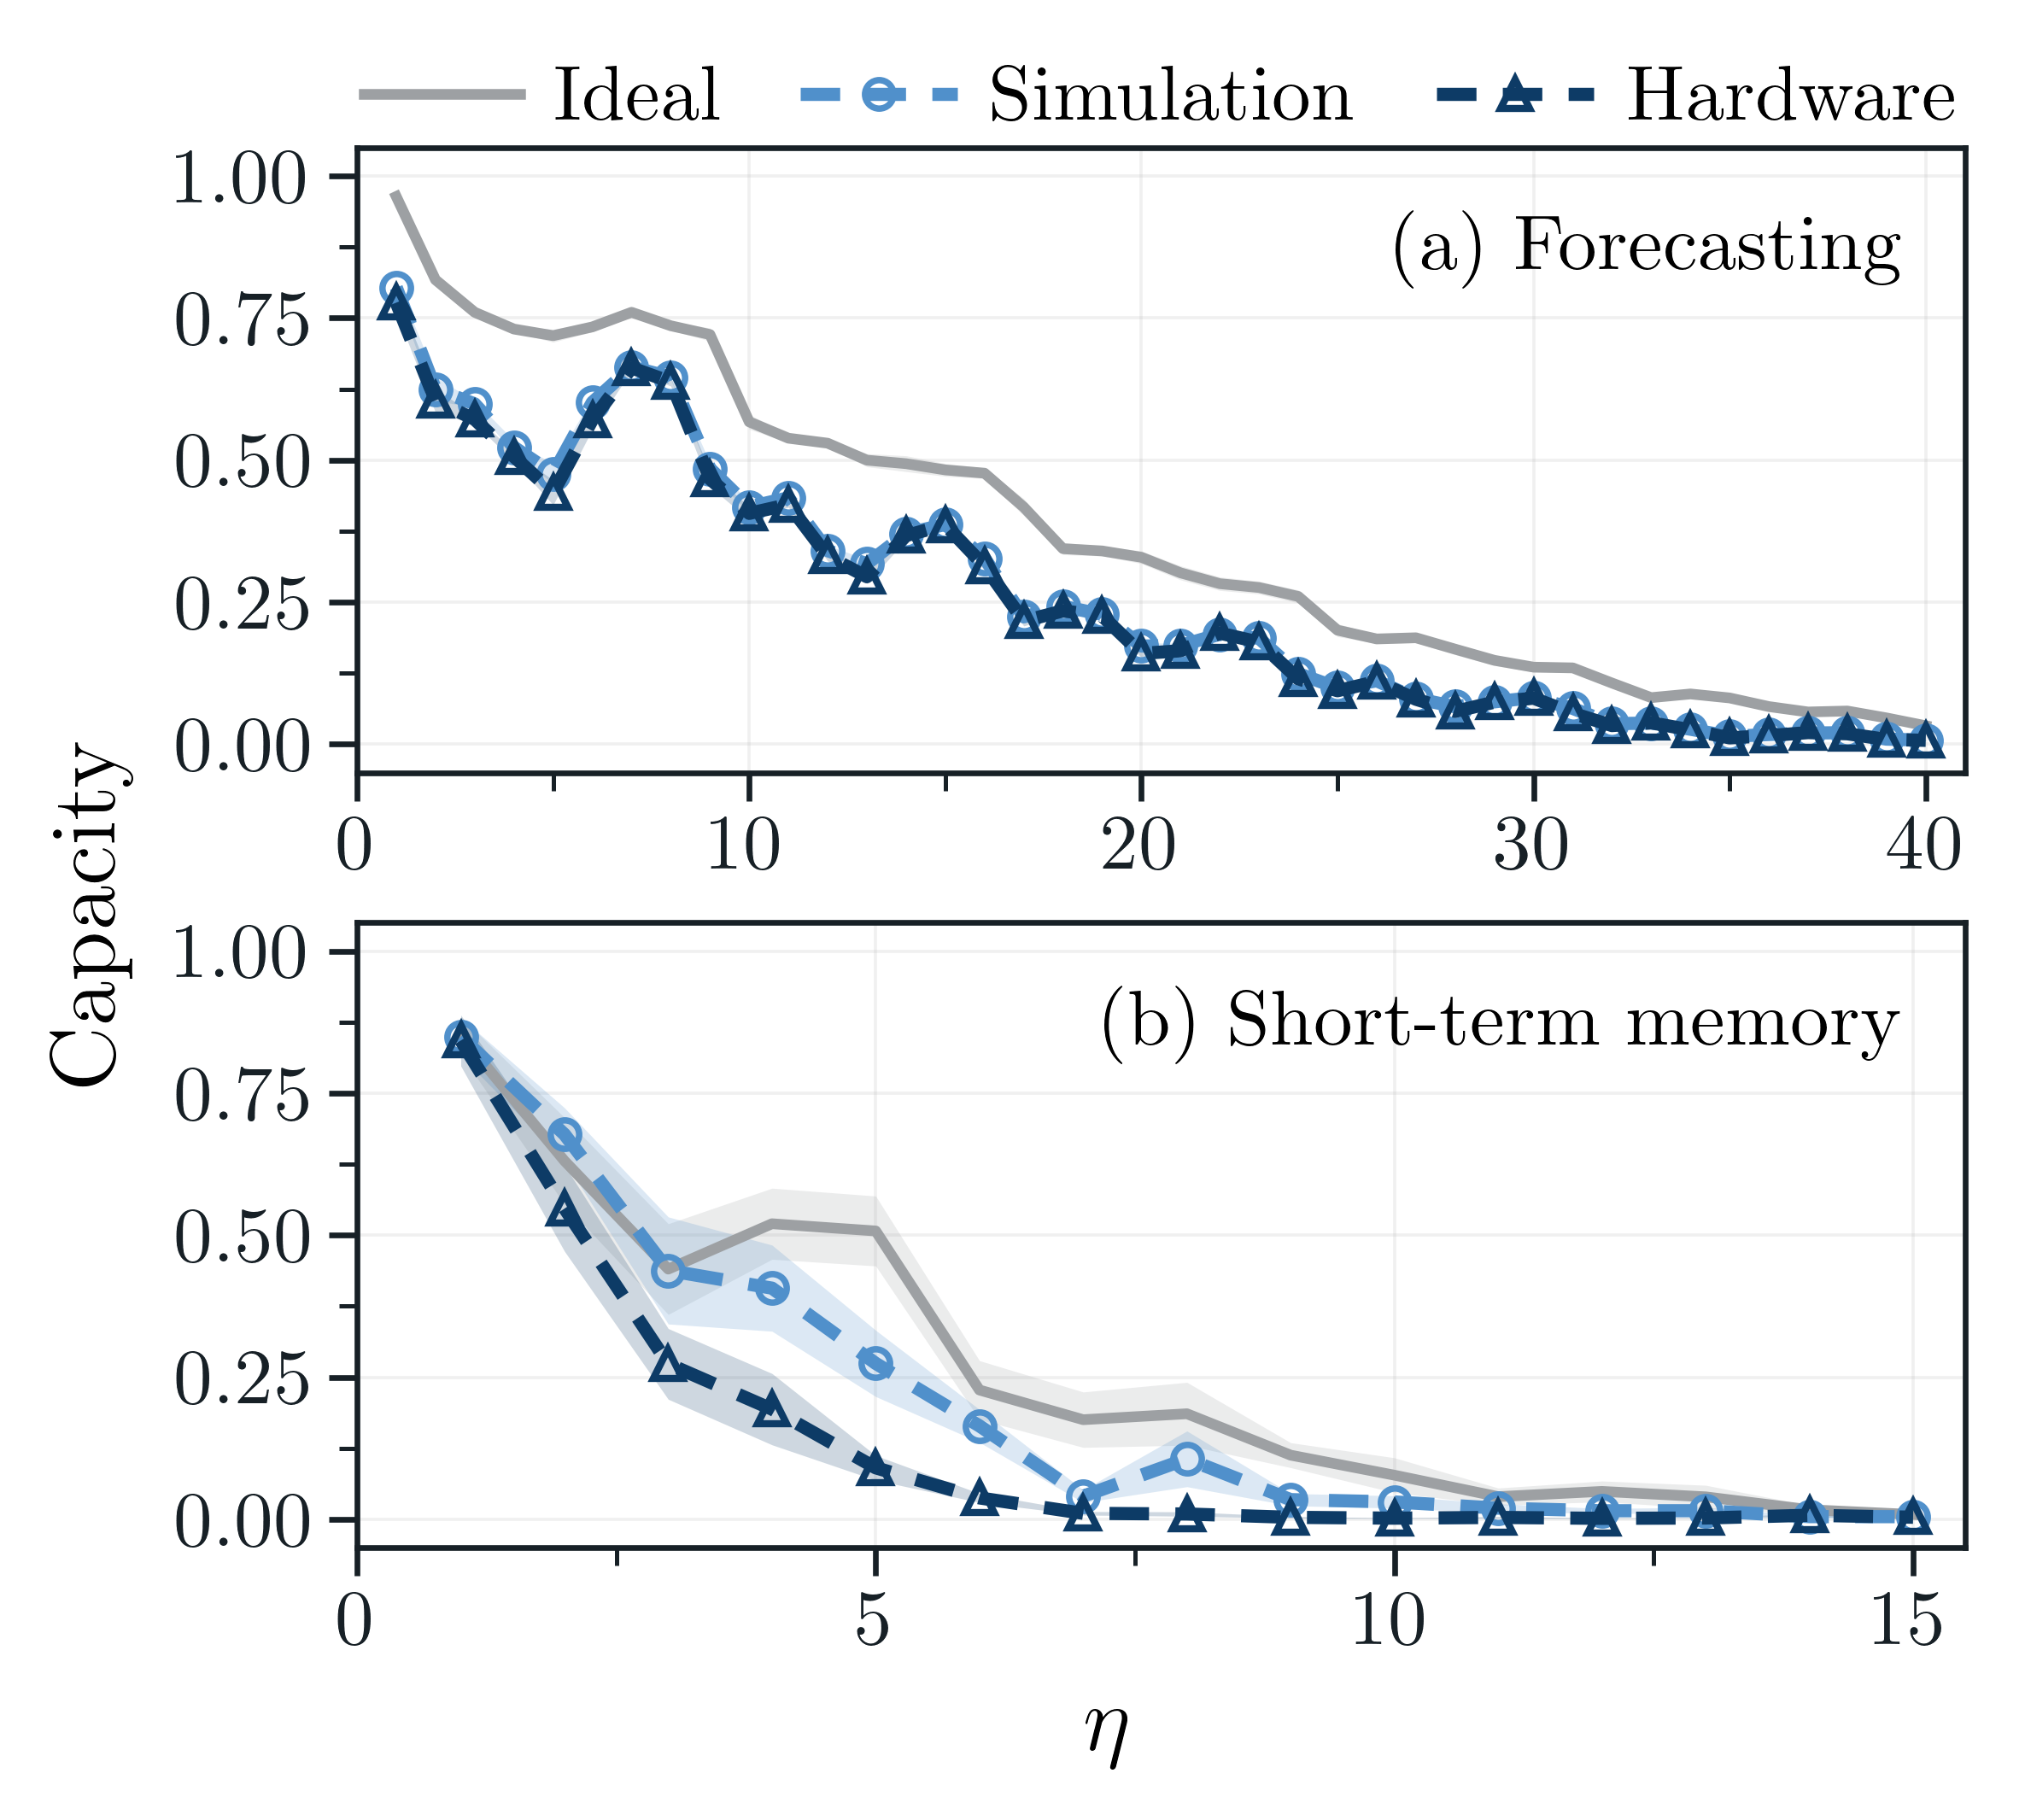

In [32]:
# Plot the two-panel benchmark-capacity figure.


plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
})

styles = {
    "ideal": dict(
        label="Ideal",
        color="#9DA0A3FF", #"#91bee7",
        marker="",
        linestyle="-",
        linewidth=1.5,
        markersize=4,
        markerfacecolor="",
        markeredgewidth=0.9,
    ),
    "sim": dict(
        label="Simulation",
        color="#5090cb",
        marker="o",
        linestyle=(0, (3, 2)),
        linewidth=1.85,
        markersize=4,
        markerfacecolor="none",
        markeredgewidth=0.9,
    ),
    "hw": dict(
        label="Hardware",
        color="#0d3b66",
        marker="^",
        linestyle=(0, (3, 2)),
        linewidth=1.85,
        markersize=4.1,
        markerfacecolor="none",
        markeredgewidth=1.0,
    ),
}

def plot_capacity_panel(ax, eta, means, sems):
    lines = []

    for key in ["ideal", "sim", "hw"]:
        st = styles[key]

        ax.fill_between(
            eta,
            means[key] - sems[key],
            means[key] + sems[key],
            color=st["color"],
            alpha=0.2 if key == "ideal" else 0.2,
            linewidth=0,
            zorder=1,
        )

        line, = ax.plot(
            eta,
            means[key],
            color=st["color"],
            marker=st["marker"],
            linestyle=st["linestyle"],
            linewidth=st["linewidth"],
            markersize=st["markersize"],
            markerfacecolor=st["markerfacecolor"],
            markeredgewidth=st["markeredgewidth"],
            markeredgecolor=st["color"],
            label=st["label"],
            zorder=3,
        )
        lines.append(line)

    ax.set_ylim(-0.05, 1.05)
    ax.set_axisbelow(True)
    ax.grid(True, which="major", alpha=0.18, linewidth=0.45)

    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    ax.tick_params(axis="both", which="major", length=4, pad=2)
    ax.tick_params(axis="both", which="minor", length=2.5)

    return lines


# Slightly wider than strict single-column because this figure has 2 panels + 3 curves
fig = plt.figure(figsize=(3.85, 3.45), dpi=600)

gs = GridSpec(
    4, 1,
    height_ratios=[
        0.15,  # legend row height
        1.00,  # top panel
        0.24,  # spacer between panels
        1.00,  # bottom panel
    ],
    hspace=0.0,
    figure=fig
)

ax_leg = fig.add_subplot(gs[0])
ax_top = fig.add_subplot(gs[1])
ax_gap = fig.add_subplot(gs[2])
ax_bottom = fig.add_subplot(gs[3])

ax_leg.axis("off")
ax_gap.axis("off")


# ===== TOP PANEL =====
eta_vec_FP = np.arange(1, 51)
lines = plot_capacity_panel(
    ax_top,
    eta_vec_FP[:40],
    means={
        "ideal": ideal_means_FP[:40],
        "sim": sim_means_FP[:40],
        "hw": hw_means_FP[:40],
    },
    sems={
        "ideal": ideal_sems_FP[:40],
        "sim": sim_sems_FP[:40],
        "hw": hw_sems_FP[:40],
    },
)

ax_top.set_xlim(0, 41)
ax_top.xaxis.set_major_locator(ticker.MultipleLocator(10))

ax_top.text(
    0.965, 0.90,
    r"(a) Forecasting",
    transform=ax_top.transAxes,
    ha="right",
    va="top",
    fontsize=11,
)


# ===== BOTTOM PANEL =====
eta_vec_STM = np.arange(1, 21)
plot_capacity_panel(
    ax_bottom,
    eta_vec_STM[:15],
    means={
        "ideal": ideal_means_STM[:15],
        "sim": sim_means_STM[:15],
        "hw": hw_means_STM[:15],
    },
    sems={
        "ideal": ideal_sems_STM[:15],
        "sim": sim_sems_STM[:15],
        "hw": hw_sems_STM[:15],
    },
)

ax_bottom.set_xlim(0, 15.5)
ax_bottom.xaxis.set_major_locator(ticker.MultipleLocator(5))

ax_bottom.text(
    0.965, 0.90,
    r"(b) Short-term memory",
    transform=ax_bottom.transAxes,
    ha="right",
    va="top",
    fontsize=11,
)


# ===== LEGEND ROW =====
ax_leg.legend(
    handles=lines,
    labels=[st["label"] for st in styles.values()],
    loc="center",
    ncol=3,
    frameon=False,
    handlelength=2.0,
    columnspacing=1.0,
    handletextpad=0.45,
    borderaxespad=0.0,
)


# ===== SHARED LABELS =====
fig.supylabel("Capacity", x=0.015, fontsize=13)
fig.supxlabel(r"$\eta$", x=0.55, y=0.015, fontsize=13)

fig.subplots_adjust(
    left=0.17,
    right=0.985,
    bottom=0.14,
    top=0.985,
)

# save the figure
#plt.savefig(OUTPUT_FIGURE_DIR / 'capacity_comparison_combined.pdf', bbox_inches='tight', dpi=600)
plt.savefig('../figures/paper/figure3.pdf', bbox_inches='tight', pad_inches=0.02)

plt.show()

## Figure 4 — optimization of the indirect-measurement strength

This section reproduces the scan over the measurement strength `g`. The spin model is used as a proxy to select the operating points later used for the hardware-tailored reservoir.

In [20]:
def read_file(data_path, seed, g):
    """Read the feature dataframe for one seed and one measurement strength."""
    file_path = Path(data_path) / f"df_g_{g}_seed_{seed}.h5"
    features_df = pd.read_hdf(file_path, key="df")
    return features_df


In [21]:
# Random Hamiltonian seeds used in the measurement-strength scan.
seeds = [60, 19, 34, 46, 47, 48, 90, 121, 136, 149]

In [22]:
# Measurement-strength grid used for the optimization scan.
g_vec = np.array([
    0.0, 0.15, 0.25641026, 0.35535593, 0.48552727,
    0.51282051, 0.59290375, 0.68880467, 0.76923077, 0.8634644,
    0.94672429, 1.02564103, 1.11210307, 1.19647414, 1.28205128,
    1.37452294, 1.4712626, 1.53846154, 1.57605565, 1.69237955,
    1.79487179, 1.82592329, 1.98727313, 2.05128205, 2.20055527,
    2.30769231, 2.56410256, 2.82051282, 3.07692308, 3.33333333,
    3.58974359, 3.84615385, 4.1025641,
])

In [28]:
# Compute summed STM capacities for each measurement strength.

np.random.seed(0)
K_STM = 1000
dataset_STM = np.random.uniform(0, 1, K_STM)
input_series_STM = dataset_STM

sum_capacities_STM = {g: [] for g in g_vec}
data_path_STM = G_SCAN_DATA_DIR / "data_STM"
eta_vec_STM = range(1, 21)

with tqdm(total=len(g_vec) * len(seeds), desc="STM") as pbar:
    for g in g_vec:
        for seed in seeds:
            df = read_file(data_path_STM, seed, g)
            capacities = [
                compute_capacity(df, input_series_STM, eta, f_p=False, train=False)
                for eta in eta_vec_STM
            ]
            sum_capacities_STM[g].append(np.sum(capacities))
            pbar.update(1)

sum_capacities_avg_STM = np.array([
    np.mean(sum_capacities_STM[g]) for g in g_vec
])
sum_capacities_sem_STM = np.array([
    np.std(sum_capacities_STM[g], ddof=1) / np.sqrt(len(sum_capacities_STM[g]))
    for g in g_vec
])


# Compute summed forecasting capacities for each measurement strength.

K_FP = 1952
dataset_FP = np.load(SANTA_FE_PATH)[:K_FP, 0]
input_series_FP = dataset_FP

sum_capacities_FP = {g: [] for g in g_vec}
data_path_FP = G_SCAN_DATA_DIR / "data_FP"
eta_vec_FP = range(1, 51)

with tqdm(total=len(g_vec) * len(seeds), desc="FP") as pbar:
    for g in g_vec:
        for seed in seeds:
            df = read_file(data_path_FP, seed, g)
            capacities = [
                compute_capacity(df, input_series_FP, eta, f_p=True, train=False)
                for eta in eta_vec_FP
            ]
            sum_capacities_FP[g].append(np.sum(capacities))
            pbar.update(1)

sum_capacities_avg_FP = np.array([
    np.mean(sum_capacities_FP[g]) for g in g_vec
])
sum_capacities_sem_FP = np.array([
    np.std(sum_capacities_FP[g], ddof=1) / np.sqrt(len(sum_capacities_FP[g]))
    for g in g_vec
])

FP: 100%|██████████| 330/330 [00:27<00:00, 11.93it/s]


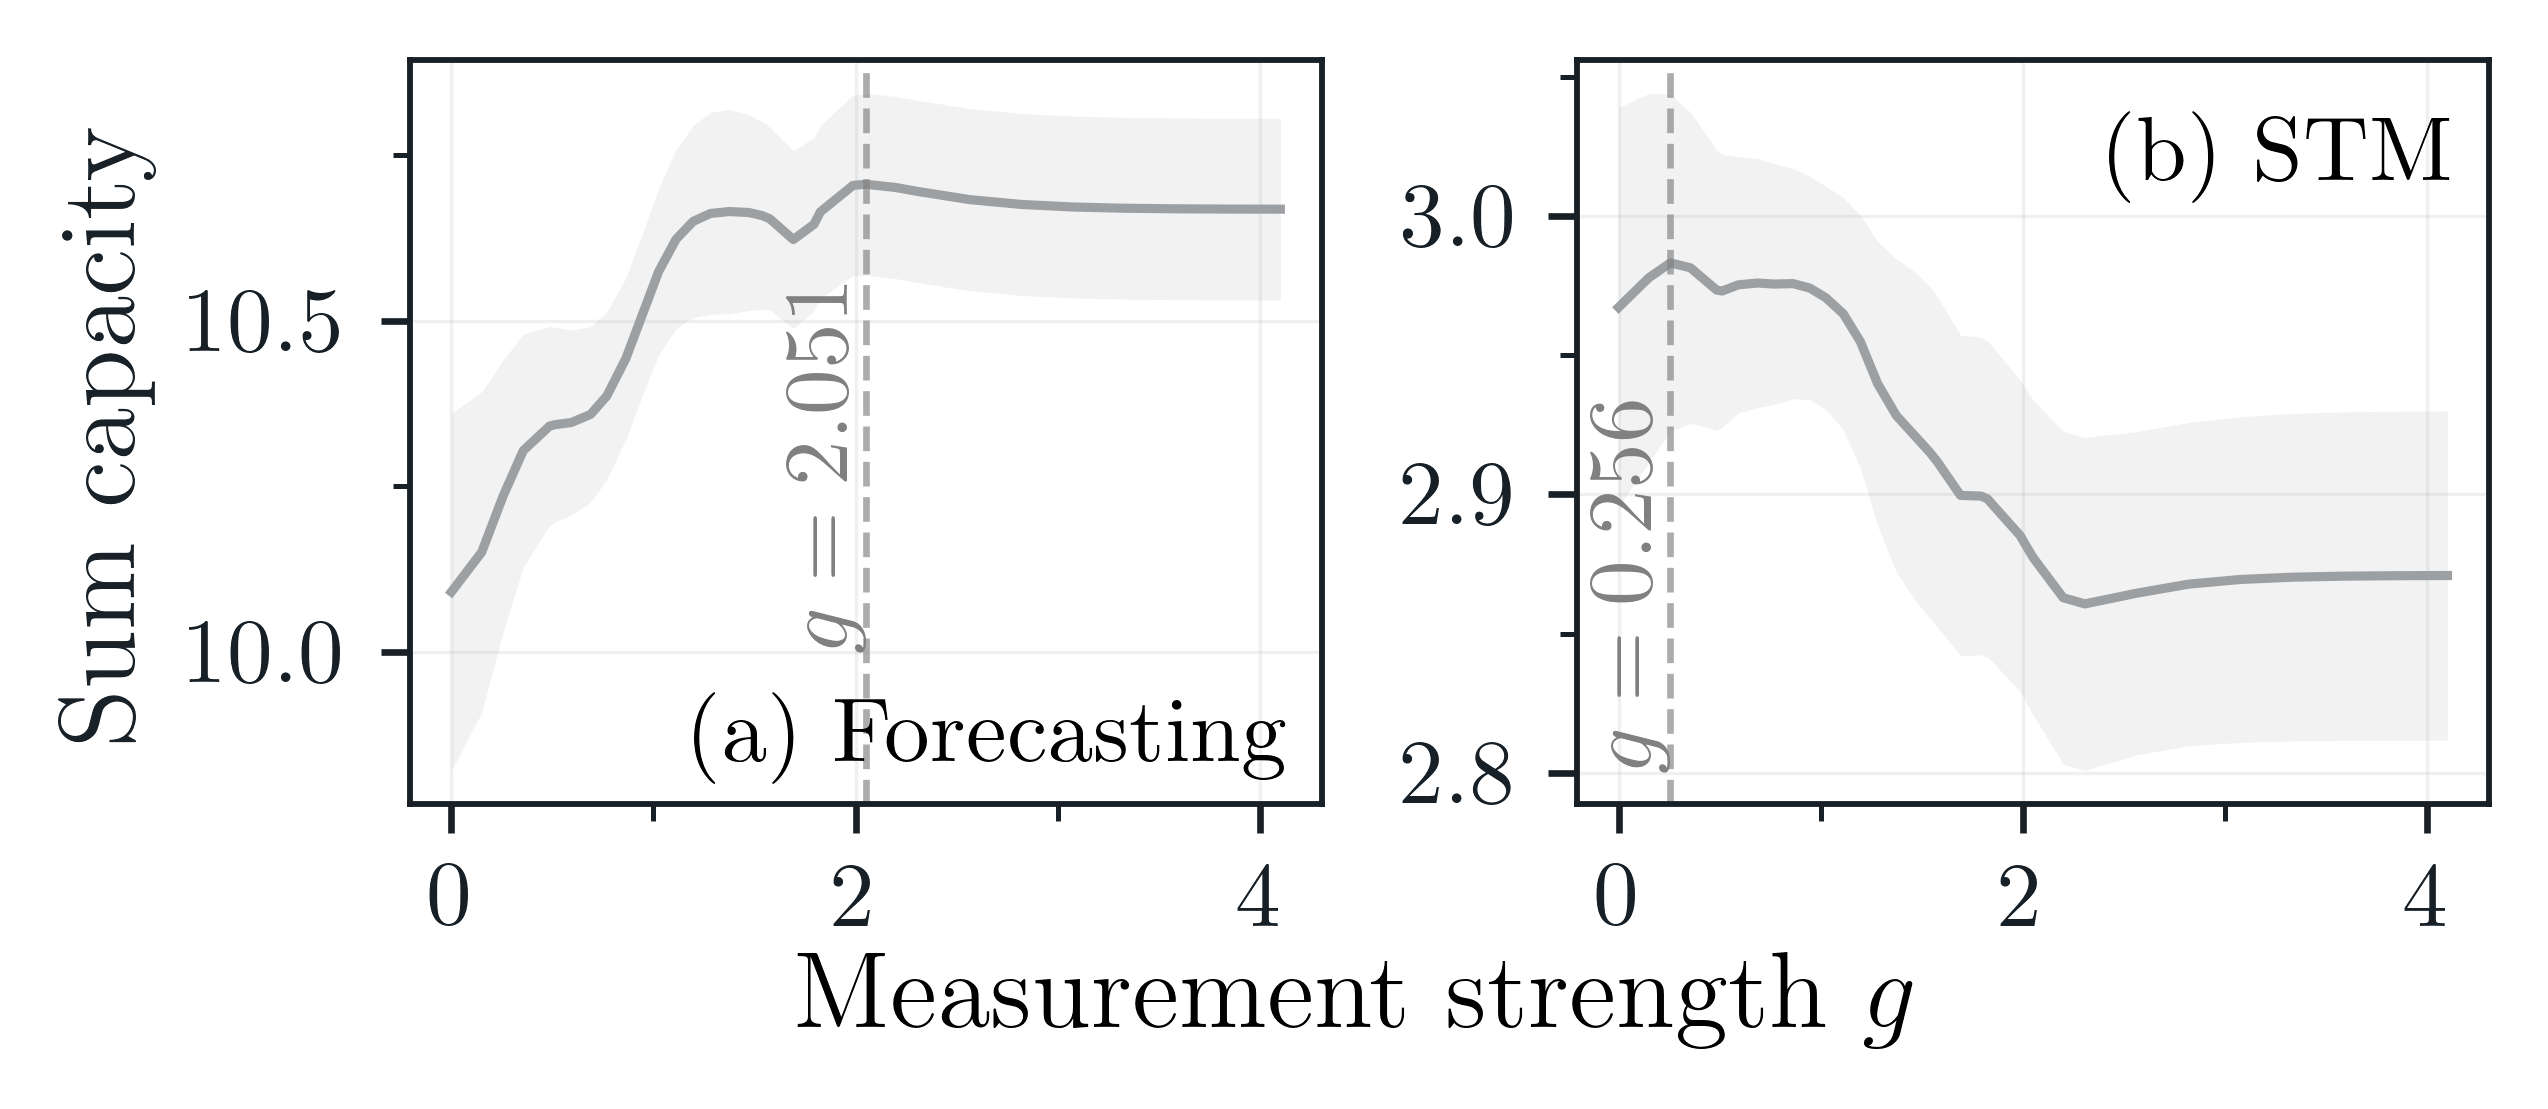

In [29]:
# ============================================================
# Combined PRL-style plot
# ============================================================

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
})

fig, (ax_fp, ax_stm) = plt.subplots(
    1, 2,
    figsize=(3.85, 1.7),
    dpi=600,
    sharex=True
)

color ="#9DA0A3FF"
band_alpha = 0.13

# ----- STM panel
ax_stm.plot(
    g_vec,
    sum_capacities_avg_STM,
    color=color,
    marker="",
    markersize=3.2,
    markerfacecolor="none",
    markeredgecolor=color,
    markeredgewidth=1.0,
    linewidth=1.1,
)

ax_stm.fill_between(
    g_vec,
    sum_capacities_avg_STM - sum_capacities_sem_STM,
    sum_capacities_avg_STM + sum_capacities_sem_STM,
    color=color,
    alpha=band_alpha,
    linewidth=0,
)

g_opt_STM = g_vec[2]
ax_stm.axvline(
    x=g_opt_STM,
    color="gray",
    linestyle="--",
    linewidth=0.8,
    alpha=0.65,
)

ax_stm.text(
    g_opt_STM,
    2.8,
    rf"$g={g_opt_STM:.3f}$",
    rotation=90,
    va="bottom",
    ha="right",
    fontsize=11,
    color="gray",
)

ax_stm.text(
    0.97, 0.93,
    r"(b) STM",
    transform=ax_stm.transAxes,
    ha="right",
    va="top",
    fontsize=11,
)

ax_stm.grid(True, alpha=0.18, linewidth=0.4)


# ----- FP panel
ax_fp.plot(
    g_vec,
    sum_capacities_avg_FP,
    color=color,
    marker="",
    markersize=3.2,
    markerfacecolor="none",
    markeredgecolor=color,
    markeredgewidth=1.0,
    linewidth=1.1,
)

ax_fp.fill_between(
    g_vec,
    sum_capacities_avg_FP - sum_capacities_sem_FP,
    sum_capacities_avg_FP + sum_capacities_sem_FP,
    color=color,
    alpha=band_alpha,
    linewidth=0,
)

g_opt_FP = g_vec[23]
ax_fp.axvline(
    x=g_opt_FP,
    color="gray",
    linestyle="--",
    linewidth=0.8,
    alpha=0.65,
)

ax_fp.text(
    g_opt_FP,
    10,
    rf"$g={g_opt_FP:.3f}$",
    rotation=90,
    va="bottom",
    ha="right",
    fontsize=11,
    color="gray",
)

ax_fp.text(
    0.97, 0.15,
    r"(a) Forecasting",
    transform=ax_fp.transAxes,
    ha="right",
    va="top",
    fontsize=11,
)
ax_fp.set_ylabel(r"Sum capacity", fontsize=13)
ax_fp.grid(True, alpha=0.18, linewidth=0.4)


# ----- Shared formatting
for ax in (ax_fp, ax_stm):
    ax.set_axisbelow(True)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    for spine in ax.spines.values():
        spine.set_linewidth(0.7)

fig.supxlabel(r"Measurement strength $g$", y=-0.02, fontsize=13)

fig.subplots_adjust(
    left=0.09,
    right=0.99,
    bottom=0.22,
    top=0.95,
    wspace=0.28,
)
# save
#plt.savefig('./figures/paper/figure_g_app.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

## Figure 5 — observable dynamics on hardware

This section compares the time-resolved expectation values for the ideal spin model, the Trotterized circuit simulation, and the hardware run. The plotted window corresponds to the STM data used in the hardware-tailored experiment.

In [33]:
# Load the STM trajectories used for the hardware-dynamics comparison.
path = HARDWARE_DATA_DIR / "exp_values_STM_basquecountry.json"
df = load_all_dfs(path, wo_window=50, K=1000)

dynamics_ideal = df["ideal"]
dynamics_sim = df["sim"]
dynamics_hw = df["hw"]

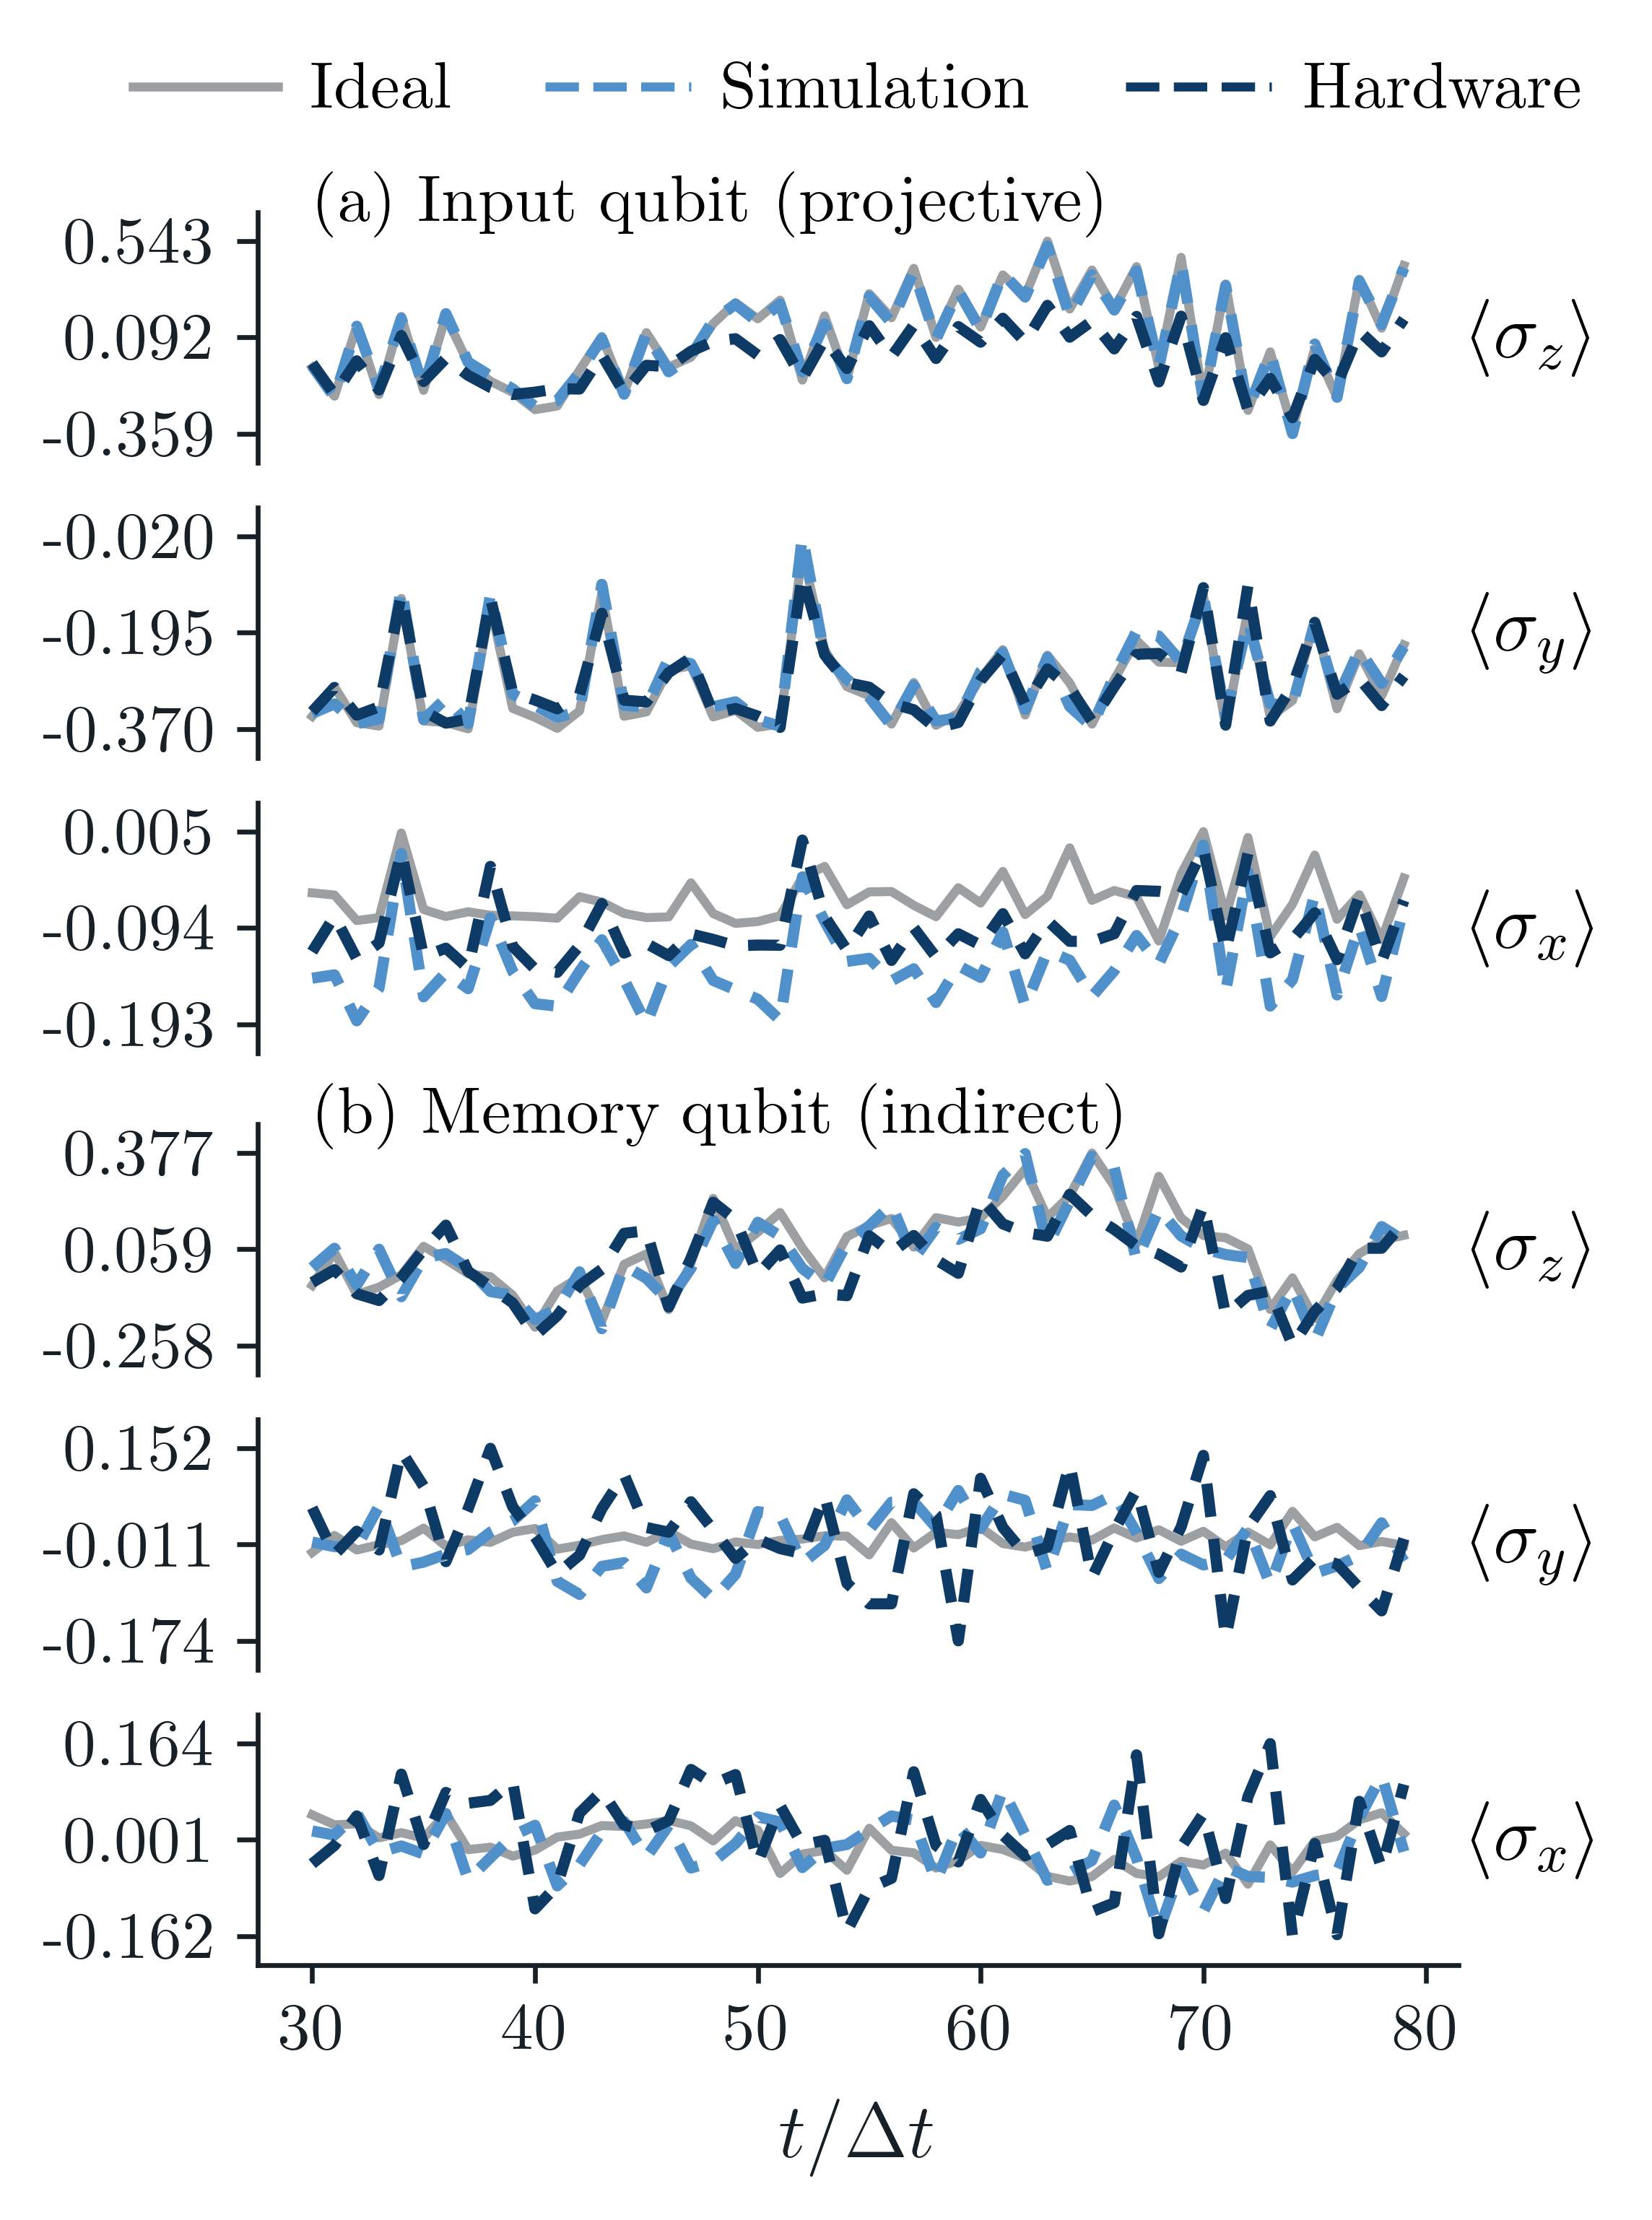

In [35]:
obs_order = ['Z', 'Y', 'X']

colors_palette = [
    "#9DA0A3FF",   # ideal
    "#5090cb",     # simulation
    "#0d3b66",     # hardware
]

markers = ['o', 'o', 'o']

K = 1000
line_w = 1.5
marker_size = 4

start = 30
end = 80
x = np.arange(K)[start:end]


# --------------------------------------------------------
# scaling, limits and ticks
# --------------------------------------------------------

def compute_lims_and_ticks(y, yq, yh, pad_frac=0.15, min_span=1e-4):
    y_all = np.concatenate([
        np.asarray(y).ravel(),
        np.asarray(yq).ravel(),
        np.asarray(yh).ravel()
    ])

    ymin, ymax = float(np.min(y_all)), float(np.max(y_all))
    span = max(ymax - ymin, min_span)

    pad = pad_frac * span
    ylim = (ymin - pad, ymax + pad)

    ticks = np.linspace(ymin, ymax, 3)
    ticklabels = [f"{t:.3f}" for t in ticks]

    return ylim, ticks, ticklabels


# --------------------------------------------------------
# plotting helper
# --------------------------------------------------------

def plot_one(ax, x, y, yq, yh, obs):

    ylim, yticks, yticklabels = compute_lims_and_ticks(y, yq, yh)

    # Ideal
    ax.plot(
        x, y,
        color=colors_palette[0],
        lw=line_w,
        zorder=2
    )

    # Circuit simulation
    ax.plot(
        x, yq,
        color=colors_palette[1],
        linestyle=(0, (3, 2)),#'--',
        linewidth=1.85,
        zorder=3
    )

    # Hardware
    ax.plot(
        x, yh,
        color=colors_palette[2],
        linestyle=(0, (3, 2)),#'--',
        linewidth=1.85,
        markersize= 4.1,
        zorder=4
    )

    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)

    ax.tick_params(axis='x', length=0)
    ax.minorticks_off()

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # observable label on right
    ax.text(
        1.01, 0.5,
        rf'$\langle \sigma_{{{obs.lower()}}}\rangle$',
        transform=ax.transAxes,
        va='center',
        ha='left',
        fontsize=13
    )


# --------------------------------------------------------
# layout with dedicated legend strip
# --------------------------------------------------------

fig = plt.figure(
    figsize=(3.85, 5.1),
    dpi=600
)

outer = fig.add_gridspec(
    3, 1,
    height_ratios=[0.35, 3, 3],
    hspace=0.12
)

# legend row
ax_leg = fig.add_subplot(outer[0])
ax_leg.axis('off')

# two stacked groups
gs_top = outer[1].subgridspec(
    3, 1,
    hspace=0.18
)

gs_bot = outer[2].subgridspec(
    3, 1,
    hspace=0.18
)

axes_in = [
    fig.add_subplot(gs_top[i,0])
    for i in range(3)
]

axes_mem = [
    fig.add_subplot(gs_bot[i,0], sharex=axes_in[0])
    for i in range(3)
]


# --------------------------------------------------------
# input qubit
# --------------------------------------------------------

for ax, obs in zip(axes_in, obs_order):

    y = np.array(
        dynamics_ideal[f"{obs}_0"][start:end]
    )

    yq = np.array(
        dynamics_sim[f"{obs}_0"][start:end]
    )

    yh = np.array(
        dynamics_hw[f"{obs}_0"][start:end]
    )

    plot_one(
        ax,
        x,
        y,
        yq,
        yh,
        obs
    )


# --------------------------------------------------------
# memory qubit
# --------------------------------------------------------

for ax, obs in zip(axes_mem, obs_order):

    y = np.array(
        dynamics_ideal[f"{obs}_1"][start:end]
    )

    yq = np.array(
        dynamics_sim[f"{obs}_1"][start:end]
    )

    yh = np.array(
        dynamics_hw[f"{obs}_1"][start:end]
    )

    plot_one(
        ax,
        x,
        y,
        yq,
        yh,
        obs
    )


# --------------------------------------------------------
# subgroup labels inside first subplot
# --------------------------------------------------------

axes_in[0].text(
    0.05, 0.9,
    r'(a) Input qubit (projective)',
    transform=axes_in[0].transAxes,
    ha='left',
    va='bottom',
    fontsize=11
)

axes_mem[0].text(
    0.05, 0.9,
    r'(b) Memory qubit (indirect)',
    transform=axes_mem[0].transAxes,
    ha='left',
    va='bottom',
    fontsize=11
)


# --------------------------------------------------------
# single horizontal legend in dedicated strip
# --------------------------------------------------------

legend_handles = [
    Line2D(
        [0],[0],
        color=colors_palette[0],
        lw=line_w,
        linestyle='-',
        label='Ideal'
    ),

    Line2D(
        [0],[0],
        color=colors_palette[1],
        lw=1.5,
        linestyle='--',
        label='Simulation'
    ),

    Line2D(
        [0],[0],
        color=colors_palette[2],
        lw=1.5,
        linestyle='--',
        label='Hardware'
    )
]

ax_leg.legend(
    handles=legend_handles,
    loc='center',
    ncol=3,
    frameon=False,
    fontsize=11,
    handlelength=2.2,
    columnspacing=1.4
)


# --------------------------------------------------------
# x-axis
# --------------------------------------------------------

for ax in axes_in:
    ax.tick_params(
        axis='x',
        labelbottom=False
    )

for ax in axes_mem[:-1]:
    ax.tick_params(
        axis='x',
        labelbottom=False
    )

axes_mem[-1].set_xlabel(
    r'$t/\Delta t$',
    fontsize=13
)

axes_mem[-1].tick_params(
    axis='x',
    length=3
)

axes_mem[-1].xaxis.labelpad = 6


# remove bottom spines except last
for ax in axes_in:
    ax.spines['bottom'].set_visible(False)

for ax in axes_mem[:-1]:
    ax.spines['bottom'].set_visible(False)


# --------------------------------------------------------
# final spacing
# --------------------------------------------------------

fig.subplots_adjust(
    top=0.96,
    bottom=0.09,
    left=0.16,
    right=0.88
)
plt.savefig('../figures/paper/figure_dyn_ap.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

## Figure 6 — output-layer contributions by observable group

This section recomputes the ideal capacities using restricted readout layers. The comparison separates all measured qubits from the input/readout qubit alone and shows which Pauli components contribute to each task.

In [32]:
# Feature groups used to restrict the readout layer.

feature_cases = {
    # All measured qubits, grouped by Pauli component.
    "all_x":  [f"X_{i}" for i in range(4)],
    "all_y":  [f"Y_{i}" for i in range(4)],
    "all_z":  [f"Z_{i}" for i in range(4)],

    "all_xz": [col for i in range(4) for col in (f"X_{i}", f"Z_{i}")],
    "all_xy": [col for i in range(4) for col in (f"X_{i}", f"Y_{i}")],
    "all_yz": [col for i in range(4) for col in (f"Y_{i}", f"Z_{i}")],

    "all_xyz": [col for i in range(4) for col in (f"X_{i}", f"Y_{i}", f"Z_{i}")],

    # Input/readout qubit only.
    "x0":    ["X_0"],
    "y0":    ["Y_0"],
    "z0":    ["Z_0"],

    "x0_y0": ["X_0", "Y_0"],
    "x0_z0": ["X_0", "Z_0"],
    "y0_z0": ["Y_0", "Z_0"],

    "x0_y0_z0": ["X_0", "Y_0", "Z_0"],
}

In [37]:
def compute_feature_case_capacities(
    task_name,
    path_base,
    seeds,
    eta_max,
    dataset,
    f_p,
    wo_window=50,
    K=None,
    path_suffix=".json",
):
    """Compute ideal capacities for several restricted readout layers.

    The function loads the ideal features for each Hamiltonian seed, restricts
    the readout layer to the selected columns, and evaluates the capacity for
    each delay.

    Returns
    -------
    capacities : dict
        Raw capacities, stored as capacities[case_name][eta].
    means : dict
        Mean capacity across Hamiltonian seeds.
    sems : dict
        Standard error of the mean across Hamiltonian seeds.
    """

    capacities = {
        case_name: {eta: [] for eta in range(1, eta_max + 1)}
        for case_name in feature_cases
    }

    for seed in seeds:
        path = str(path_base)
        if seed is not None:
            path += f"_{seed}"
        path += path_suffix

        if K is None:
            dfs = load_all_dfs(path, wo_window=wo_window)
        else:
            dfs = load_all_dfs(path, wo_window=wo_window, K=K)

        df_ideal = dfs["ideal"]

        for case_name, cols in feature_cases.items():
            df_case = df_ideal[cols]

            for eta in range(1, eta_max + 1):
                cap = compute_capacity(df_case, dataset, eta, f_p=f_p)
                capacities[case_name][eta].append(cap)

    means = {
        case_name: {
            eta: np.mean(capacities[case_name][eta])
            for eta in capacities[case_name]
        }
        for case_name in capacities
    }

    sems = {
        case_name: {
            eta: np.std(capacities[case_name][eta], ddof=1)
            / np.sqrt(len(capacities[case_name][eta]))
            for eta in capacities[case_name]
        }
        for case_name in capacities
    }

    print(f"Done: {task_name}")

    return capacities, means, sems

In [38]:
# Compute feature-restricted ideal capacities for STM.

seeds_STM = [None, 19, 34, 46, 47, 48, 90, 121, 136, 149]

K_STM = 1000
np.random.seed(0)
dataset_STM = np.random.uniform(0, 1, K_STM)

capacities_ideal_STM_cases, means_ideal_STM_cases, sems_ideal_STM_cases = (
    compute_feature_case_capacities(
        task_name="STM",
        path_base=HARDWARE_DATA_DIR / "exp_values_STM_basquecountry",
        seeds=seeds_STM,
        eta_max=20,
        dataset=dataset_STM,
        f_p=False,
        wo_window=50,
        K=None,
        path_suffix=".json",
    )
)

eta_vec_STM = np.arange(1, 21)

means_ideal_STM_arrays = {
    case_name: np.array([means_ideal_STM_cases[case_name][eta] for eta in eta_vec_STM])
    for case_name in feature_cases
}

sems_ideal_STM_arrays = {
    case_name: np.array([sems_ideal_STM_cases[case_name][eta] for eta in eta_vec_STM])
    for case_name in feature_cases
}

# Compute feature-restricted ideal capacities for forecasting.

seeds_FP = [60, 19, 34, 46, 47, 48, 90, 121, 136, 149]

K_FP = 1952
dataset_FP = np.load(SANTA_FE_PATH)[:K_FP, 0]

capacities_ideal_FP_cases, means_ideal_FP_cases, sems_ideal_FP_cases = (
    compute_feature_case_capacities(
        task_name="FP",
        path_base=HARDWARE_DATA_DIR / "exp_values_FP_basquecountry",
        seeds=seeds_FP,
        eta_max=50,
        dataset=dataset_FP,
        f_p=True,
        wo_window=50,
        K=K_FP,
        path_suffix="_g2.json",
    )
)

eta_vec_FP = np.arange(1, 51)

means_ideal_FP_arrays = {
    case_name: np.array([means_ideal_FP_cases[case_name][eta] for eta in eta_vec_FP])
    for case_name in feature_cases
}

sems_ideal_FP_arrays = {
    case_name: np.array([sems_ideal_FP_cases[case_name][eta] for eta in eta_vec_FP])
    for case_name in feature_cases
}

Done: STM
Done: FP


In [39]:
# Case groups shown in the two rows of Fig. 6.

all_pauli_cases = [
    "all_x",
    "all_y",
    "all_z",
    "all_xz",
    "all_xy",
    "all_yz",
    "all_xyz",
]

single_qubit_cases = [
    "x0",
    "y0",
    "z0",
    "x0_y0",
    "x0_z0",
    "y0_z0",
    "x0_y0_z0",
]

case_labels = {
    "all_x": r"$X$",
    "all_y": r"$Y$",
    "all_z": r"$Z$",
    "all_xz": r"$XZ$",
    "all_xy": r"$XY$",
    "all_yz": r"$YZ$",
    "all_xyz": r"$XYZ$",

    "x0": r"$X_0$",
    "y0": r"$Y_0$",
    "z0": r"$Z_0$",
    "x0_y0": r"$X_0Y_0$",
    "x0_z0": r"$X_0Z_0$",
    "y0_z0": r"$Y_0Z_0$",
    "x0_y0_z0": r"$X_0Y_0Z_0$",
}


# Styles for the seven feature cases.

case_styles = {
    "all_x": dict(color="#4C78A8", marker="o", linestyle="-"),
    "all_y": dict(color="#F58518", marker="s", linestyle="-"),
    "all_z": dict(color="#54A24B", marker="^", linestyle="-"),
    "all_xz": dict(color="#B279A2", marker="D", linestyle="--"),
    "all_xy": dict(color="#E45756", marker="v", linestyle="--"),
    "all_yz": dict(color="#72B7B2", marker="P", linestyle="--"),
    "all_xyz": dict(color="#222222", marker="", linestyle="-"),

    "x0": dict(color="#4C78A8", marker="o", linestyle="-"),
    "y0": dict(color="#F58518", marker="s", linestyle="-"),
    "z0": dict(color="#54A24B", marker="^", linestyle="-"),
    "x0_y0": dict(color="#B279A2", marker="D", linestyle="--"),
    "x0_z0": dict(color="#E45756", marker="v", linestyle="--"),
    "y0_z0": dict(color="#72B7B2", marker="P", linestyle="--"),
    "x0_y0_z0": dict(color="#222222", marker="", linestyle="-"),
}


# ============================================================
# Generic panel plotting function
# ============================================================

def plot_feature_capacity_panel(
    ax,
    eta,
    means_arrays,
    sems_arrays,
    cases,
    eta_max=None,
    show_legend_handles=False,
):
    lines = []

    if eta_max is not None:
        eta_plot = eta[:eta_max]
    else:
        eta_plot = eta

    for case in cases:
        st = case_styles[case]

        if eta_max is not None:
            mean = means_arrays[case][:eta_max]
            sem = sems_arrays[case][:eta_max]
        else:
            mean = means_arrays[case]
            sem = sems_arrays[case]

        ax.fill_between(
            eta_plot,
            mean - sem,
            mean + sem,
            color=st["color"],
            alpha=0.07,
            linewidth=0,
            zorder=1,
        )

        line, = ax.plot(
            eta_plot,
            mean,
            color=st["color"],
            marker=st["marker"],
            linestyle=st["linestyle"],
            linewidth=1.15 if case not in ["all_xyz", "x0_y0_z0"] else 1.35,
            markersize=3.4,
            markerfacecolor="none",
            markeredgewidth=0.8,
            markeredgecolor=st["color"],
            label=case_labels[case],
            zorder=3,
        )

        lines.append(line)

    ax.set_ylim(-0.05, 1.05)
    ax.set_axisbelow(True)
    ax.grid(True, which="major", alpha=0.18, linewidth=0.45)

    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    ax.tick_params(axis="both", which="major", length=4, pad=2)
    ax.tick_params(axis="both", which="minor", length=2.5)

    if show_legend_handles:
        return lines

    return None

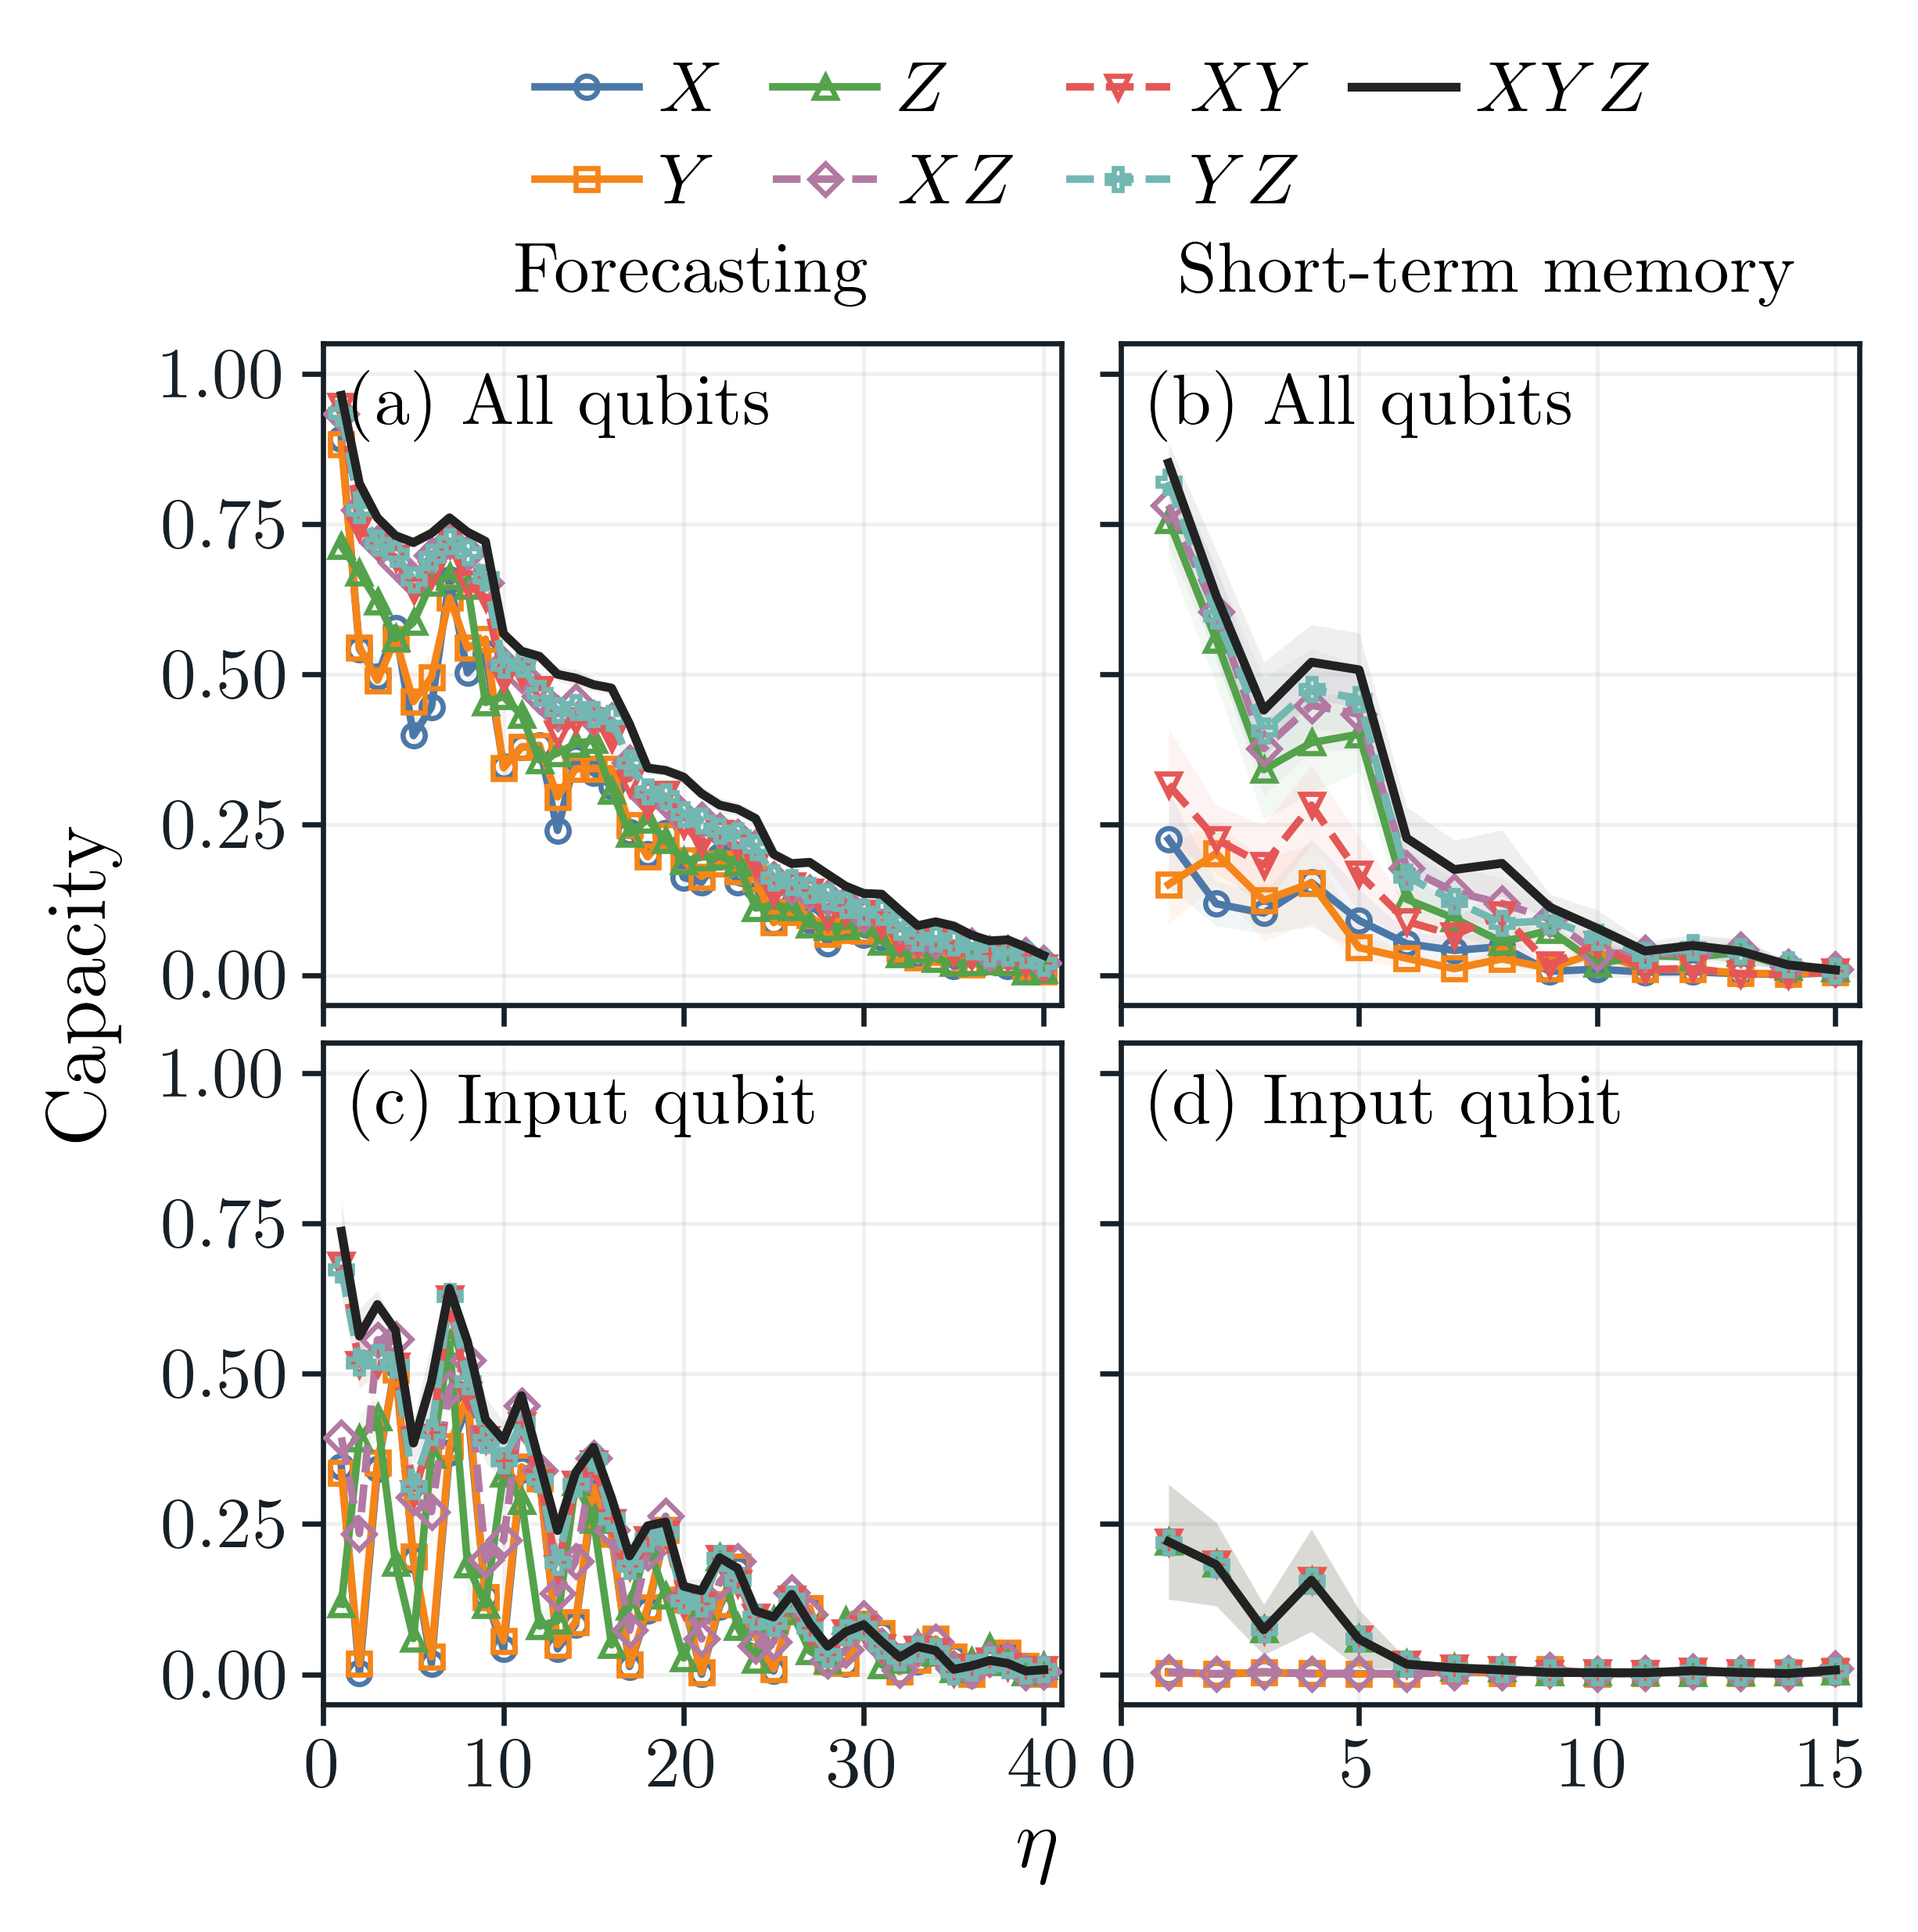

In [40]:
# Plot the four-panel observable-contribution figure.
(OUTPUT_FIGURE_DIR / "paper").mkdir(parents=True, exist_ok=True)


eta_vec_FP = np.arange(1, 51)
eta_vec_STM = np.arange(1, 21)

# Font sizes.

AXIS_LABEL_FS = 13
COLUMN_TITLE_FS = 11
TICK_FS = 11
PANEL_LABEL_FS = 11
LEGEND_FS = 11

# Paper-style plotting settings.
plt.rcParams.update({
    "font.size": TICK_FS,
    "axes.labelsize": AXIS_LABEL_FS,
    "xtick.labelsize": TICK_FS,
    "ytick.labelsize": TICK_FS,
    "legend.fontsize": LEGEND_FS,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
})

fig = plt.figure(figsize=(3.85, 4.05), dpi=600)

# 4 rows:
# 0 = legend
# 1 = column titles
# 2 = all-qubits panels
# 3 = input-qubit panels
gs = GridSpec(
    4, 2,
    height_ratios=[0.18, 0.105, 1.00, 1.00],
    hspace=0.10,
    wspace=0.08,
    figure=fig,
)

# ============================================================
# Axes
# ============================================================

ax_leg = fig.add_subplot(gs[0, :])
ax_leg.axis("off")

ax_title_fp = fig.add_subplot(gs[1, 0])
ax_title_stm = fig.add_subplot(gs[1, 1])

for ax in [ax_title_fp, ax_title_stm]:
    ax.axis("off")

ax_fp_all = fig.add_subplot(gs[2, 0])
ax_stm_all = fig.add_subplot(gs[2, 1], sharey=ax_fp_all)

ax_fp_q0 = fig.add_subplot(gs[3, 0])
ax_stm_q0 = fig.add_subplot(gs[3, 1], sharey=ax_fp_q0)


# ============================================================
# Helper function
# ============================================================

def add_panel_label(ax, label, x=0.04, y=0.96, fontsize=PANEL_LABEL_FS):
    ax.text(
        x, y,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=fontsize,
    )


# ============================================================
# Column titles
# ============================================================

ax_title_fp.text(
    0.5, 0.45,
    "Forecasting",
    ha="center",
    va="center",
    fontsize=COLUMN_TITLE_FS,
)

ax_title_stm.text(
    0.5, 0.45,
    "Short-term memory",
    ha="center",
    va="center",
    fontsize=COLUMN_TITLE_FS,
)


# ============================================================
# (a) Forecasting, all qubits
# ============================================================

lines_all = plot_feature_capacity_panel(
    ax_fp_all,
    eta_vec_FP,
    means_ideal_FP_arrays,
    sems_ideal_FP_arrays,
    all_pauli_cases,
    eta_max=40,
    show_legend_handles=True,
)

ax_fp_all.set_xlim(0, 41)
ax_fp_all.xaxis.set_major_locator(ticker.MultipleLocator(10))
add_panel_label(ax_fp_all, r"(a) All qubits")


# ============================================================
# (b) STM, all qubits
# ============================================================

plot_feature_capacity_panel(
    ax_stm_all,
    eta_vec_STM,
    means_ideal_STM_arrays,
    sems_ideal_STM_arrays,
    all_pauli_cases,
    eta_max=15,
)

ax_stm_all.set_xlim(0, 15.5)
ax_stm_all.xaxis.set_major_locator(ticker.MultipleLocator(5))
add_panel_label(ax_stm_all, r"(b) All qubits")


# ============================================================
# (c) Forecasting, input qubit
# ============================================================

lines_q0 = plot_feature_capacity_panel(
    ax_fp_q0,
    eta_vec_FP,
    means_ideal_FP_arrays,
    sems_ideal_FP_arrays,
    single_qubit_cases,
    eta_max=40,
    show_legend_handles=True,
)

ax_fp_q0.set_xlim(0, 41)
ax_fp_q0.xaxis.set_major_locator(ticker.MultipleLocator(10))
add_panel_label(ax_fp_q0, r"(c) Input qubit")


# ============================================================
# (d) STM, input qubit
# ============================================================

plot_feature_capacity_panel(
    ax_stm_q0,
    eta_vec_STM,
    means_ideal_STM_arrays,
    sems_ideal_STM_arrays,
    single_qubit_cases,
    eta_max=15,
)

ax_stm_q0.set_xlim(0, 15.5)
ax_stm_q0.xaxis.set_major_locator(ticker.MultipleLocator(5))
add_panel_label(ax_stm_q0, r"(d) Input qubit")


# ============================================================
# Common axis formatting
# ============================================================

for ax in [ax_fp_all, ax_stm_all, ax_fp_q0, ax_stm_q0]:
    ax.set_ylim(-0.05, 1.05)

    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

    ax.yaxis.set_minor_locator(ticker.NullLocator())
    ax.xaxis.set_minor_locator(ticker.NullLocator())

    ax.grid(True, which="major", alpha=0.18, linewidth=0.6)

    ax.tick_params(axis="both", which="major", length=3.2, width=0.8, labelsize=TICK_FS)
    ax.tick_params(axis="both", which="minor", length=0)

# right column: remove duplicated y tick labels
ax_stm_all.tick_params(labelleft=False)
ax_stm_q0.tick_params(labelleft=False)

# top data row: remove duplicated x tick labels
ax_fp_all.tick_params(labelbottom=False)
ax_stm_all.tick_params(labelbottom=False)


# ============================================================
# Legend
# ============================================================

ax_leg.legend(
    handles=lines_all,
    labels=[case_labels[c] for c in all_pauli_cases],
    loc="center",
    ncol=4,
    frameon=False,
    fontsize=LEGEND_FS,
    handlelength=1.45,
    columnspacing=0.75,
    handletextpad=0.30,
    borderaxespad=0.0,
)


# ============================================================
# Shared labels and margins
# ============================================================

fig.supylabel("Capacity", x=-0.008, fontsize=AXIS_LABEL_FS)
fig.supxlabel(r"$\eta$", x=0.54, y=0.025, fontsize=AXIS_LABEL_FS)

fig.subplots_adjust(
    left=0.145,
    right=0.995,
    bottom=0.12,
    top=0.975,
)

# ============================================================
# Save
# ============================================================

"""plt.savefig(
    OUTPUT_FIGURE_DIR / "paper" / "figure6.pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)"""

plt.show()